In [ ]:
import time
from pathlib import Path

import pandas as pd 
import numpy as np

import joblib

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing


RANDOM_STATE = 525458

In [ ]:
FOLDER = Path.cwd().parent
DATA_RUTE = FOLDER / 'Data'

historico_equipos = pd.read_csv(DATA_RUTE / 'historico_equipos.csv', index_col=[0], parse_dates=[0])
historico_equipos.sort_index(inplace=True)

data_x = pd.read_csv(DATA_RUTE / 'X.csv', index_col=[0], parse_dates=[0])
data_x.sort_index(inplace=True)

# Warning por errores en el formato del csv
data_y = pd.read_csv(DATA_RUTE / 'Y.csv', index_col=[0], parse_dates=[0], dayfirst=True, sep=';', decimal=',')
data_y.sort_index(inplace=True)

# Las columnas están invertidas
data_z = pd.read_csv(DATA_RUTE / 'Z.csv', index_col='Date', parse_dates=['Date'])
data_z.sort_index(inplace=True)

print('El índice es creciente:',historico_equipos.index.is_monotonic_increasing, '\n')

print('Tamaños de los Datasets: Filas/Columnas')
print(historico_equipos.shape, data_x.shape, data_y.shape, data_z.shape)

El indice es creciente: True 

Tamaños de los Datasets: Filas/Columnas
(3530, 5) (9144, 1) (4485, 1) (3565, 1)


In [3]:
historico_equipos.columns

Index(['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2'], dtype='str')

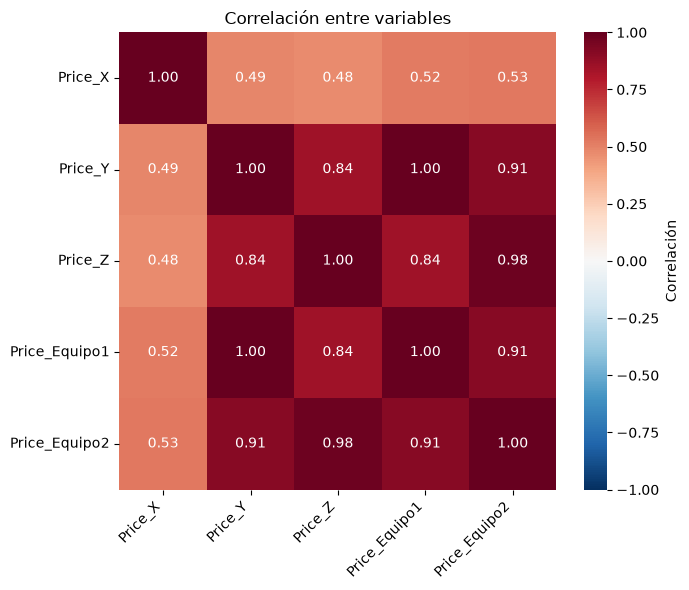

In [4]:
# Matriz de correlaciones 

cols_corr = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']

corr = historico_equipos[cols_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, cbar_kws={'label': 'Correlación'}, annot_kws={'size': 10})

ax.set_title('Correlación entre variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
fig.tight_layout()
plt.show()


In [5]:
price_y_model = historico_equipos[['Price_Y']].copy()

In [6]:
price_y_model.tail()

,Price_Y
Date,
2023-08-25,554.00
2023-08-28,549.00
2023-08-29,545.33
2023-08-30,543.67
2023-08-31,545.00


In [7]:
price_y_month_mean = price_y_model.resample('ME').mean()

In [8]:
price_y_month_mean

,Price_Y
Date,
2010-01-31,547.000000
2010-02-28,538.000000
2010-03-31,606.630435
2010-04-30,682.976190
2010-05-31,679.642857
...,...
2023-04-30,603.885789
2023-05-31,550.593913
2023-06-30,541.775909


In [9]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        col_name = data.columns[0]
        data['lag_{}'.format(lag)] = data[col_name].shift(lag)
    data['rolling_mean'] = (
        data[col_name].shift().rolling(rolling_mean_size).mean()
    )

# max_lag= 12 para capturar los movimientos durante el año 
# 
make_features(price_y_month_mean, 12, 3)

price_y_month_mean.head(20)

,Price_Y,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean
Date,,,,,,,,,,,,,,,,,,
2010-01-31,547.000000,2010,1,31,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,538.000000,2010,2,28,6,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,606.630435,2010,3,31,2,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,682.976190,2010,4,30,4,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,563.876812
2010-05-31,679.642857,2010,5,31,0,682.976190,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,609.202208
2010-06-30,614.204545,2010,6,30,2,679.642857,682.976190,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,656.416494
2010-07-31,606.136364,2010,7,31,5,614.204545,679.642857,682.976190,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,658.941198
2010-08-31,632.045455,2010,8,31,1,606.136364,614.204545,679.642857,682.976190,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,633.327922
2010-09-30,627.045455,2010,9,30,3,632.045455,606.136364,614.204545,679.642857,682.976190,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,617.462121


In [10]:
price_y_month_mean

,Price_Y,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean
Date,,,,,,,,,,,,,,,,,,
2010-01-31,547.000000,2010,1,31,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,538.000000,2010,2,28,6,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,606.630435,2010,3,31,2,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,682.976190,2010,4,30,4,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,563.876812
2010-05-31,679.642857,2010,5,31,0,682.976190,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,609.202208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-30,603.885789,2023,4,30,6,641.466957,629.608500,632.670952,584.590952,534.521364,551.018571,563.752727,596.376957,611.174762,714.924545,768.985455,853.216000,634.582136
2023-05-31,550.593913,2023,5,31,2,603.885789,641.466957,629.608500,632.670952,584.590952,534.521364,551.018571,563.752727,596.376957,611.174762,714.924545,768.985455,624.987082
2023-06-30,541.775909,2023,6,30,4,550.593913,603.885789,641.466957,629.608500,632.670952,584.590952,534.521364,551.018571,563.752727,596.376957,611.174762,714.924545,598.648886


In [11]:
train, test = train_test_split(price_y_month_mean, shuffle=False, test_size=0.2)
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2010-01-31 00:00:00 2020-11-30 00:00:00
2020-12-31 00:00:00 2023-08-31 00:00:00


In [12]:
# Modelo base sobre la mediana 
train_median = train['Price_Y'].median()
print('Precio diario y:', test['Price_Y'].median())

pred_median = np.ones(test.shape) * train_median
print('MAE:', mean_absolute_error(pred_median, test))

print()

Precio diario y: 660.563
MAE: 315.93603965312695



In [13]:
# Modelo sobre el Mes anterior
print('Precio diario y:', test['Price_Y'].median())
pred_previous = test['Price_Y'].shift()
pred_previous.iloc[0] = train['Price_Y'].iloc[-1]
print('MAE:', mean_absolute_error(test['Price_Y'], pred_previous))

Precio diario y: 660.563
MAE: 39.53250191924896


In [14]:

train = train.dropna()

features_train = train.drop('Price_Y', axis=1)  
target_train   = train['Price_Y']

features_test  = test.drop('Price_Y', axis=1)
target_test    = test['Price_Y']



In [15]:
# Cambiar los nombre de los modelos TODO mara no mezclar  PriceY y PriceZ
model = LinearRegression()
model.fit(features_train, target_train) 

pred_train = model.predict(features_train)
pred_test  = model.predict(features_test)

print("EAM para el conjunto de entrenamiento:", mean_absolute_error(target_train, pred_train))
print("EAM para el conjunto de prueba:", mean_absolute_error(target_test,  pred_test))

EAM para el conjunto de entrenamiento: 15.912641574148365
EAM para el conjunto de prueba: 38.537855329738


In [16]:


model_forest = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
model_forest.fit(features_train, target_train)


pediction_forest= model_forest.predict(features_test)

pediction_forest_test = model_forest.predict(features_train)

print("RECM  para el conjunto de entrenamiento:", root_mean_squared_error(target_train, pediction_forest_test))
print("RECM  para el conjunto de prueba:",        root_mean_squared_error(target_test,  pediction_forest))

RECM  para el conjunto de entrenamiento: 11.449368584929369
RECM  para el conjunto de prueba: 125.11030158324556


In [17]:
price_y_month_mean

,Price_Y,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean
Date,,,,,,,,,,,,,,,,,,
2010-01-31,547.000000,2010,1,31,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,538.000000,2010,2,28,6,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,606.630435,2010,3,31,2,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,682.976190,2010,4,30,4,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,563.876812
2010-05-31,679.642857,2010,5,31,0,682.976190,606.630435,538.000000,547.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,609.202208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-30,603.885789,2023,4,30,6,641.466957,629.608500,632.670952,584.590952,534.521364,551.018571,563.752727,596.376957,611.174762,714.924545,768.985455,853.216000,634.582136
2023-05-31,550.593913,2023,5,31,2,603.885789,641.466957,629.608500,632.670952,584.590952,534.521364,551.018571,563.752727,596.376957,611.174762,714.924545,768.985455,624.987082
2023-06-30,541.775909,2023,6,30,4,550.593913,603.885789,641.466957,629.608500,632.670952,584.590952,534.521364,551.018571,563.752727,596.376957,611.174762,714.924545,598.648886


In [18]:
# 'El método Holt-Winters se basa en una típica descomposición de la serie de tiempo,
# donde se le asigna mayor peso a las observaciones más recientes'.
# REF https://medium.com/tacosdedatos/herramientas-para-pron%C3%B3sticos-de-series-de-tiempo-en-python-parte-2-holt-winters-adb1bd0d7b84

serie_temporal = price_y_month_mean['Price_Y'].dropna()

serie_temporal

Date
2010-01-31    547.000000
2010-02-28    538.000000
2010-03-31    606.630435
2010-04-30    682.976190
2010-05-31    679.642857
                 ...    
2023-04-30    603.885789
2023-05-31    550.593913
2023-06-30    541.775909
2023-07-31    554.357619
2023-08-31    556.303913
Freq: ME, Name: Price_Y, Length: 164, dtype: float64

In [19]:
model_hw_z = ExponentialSmoothing(serie_temporal, trend='add', seasonal='add',seasonal_periods=12)

model_hw_train_z = model_hw_z.fit()

proyeccion_z = model_hw_train_z.forecast(6)

print(proyeccion_z)

2023-09-30    552.498007
2023-10-31    537.937013
2023-11-30    528.544562
2023-12-31    543.805580
2024-01-31    555.009206
2024-02-29    564.717674
Freq: ME, dtype: float64


## Price Z

In [20]:
price_z_model = historico_equipos[['Price_Z']].copy()
col_name_z = price_z_model.columns[0]
col_name_z

'Price_Z'

In [21]:
price_z_month = price_z_model.resample('ME').mean()

In [22]:
price_z_month

,Price_Z
Date,
2010-01-31,2234.325000
2010-02-28,2048.575000
2010-03-31,2204.130435
2010-04-30,2313.083333
2010-05-31,2048.666667
...,...
2023-04-30,2336.763158
2023-05-31,2271.586957
2023-06-30,2180.738636


In [23]:
make_features(price_z_month, 12, 3)

price_z_month.head(10)

,Price_Z,year,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean
Date,,,,,,,,,,,,,,,,,,
2010-01-31,2234.325000,2010,1,31,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,2048.575000,2010,2,28,6,2234.325000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,2204.130435,2010,3,31,2,2048.575000,2234.325000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,2313.083333,2010,4,30,4,2204.130435,2048.575000,2234.325000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2162.343478
2010-05-31,2048.666667,2010,5,31,0,2313.083333,2204.130435,2048.575000,2234.325000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2188.596256
2010-06-30,1931.022727,2010,6,30,2,2048.666667,2313.083333,2204.130435,2048.575000,2234.325000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2188.626812
2010-07-31,1987.784091,2010,7,31,5,1931.022727,2048.666667,2313.083333,2204.130435,2048.575000,2234.325000,NaN,NaN,NaN,NaN,NaN,NaN,2097.590909
2010-08-31,2116.079545,2010,8,31,1,1987.784091,1931.022727,2048.666667,2313.083333,2204.130435,2048.575000,2234.325000,NaN,NaN,NaN,NaN,NaN,1989.157828
2010-09-30,2161.443182,2010,9,30,3,2116.079545,1987.784091,1931.022727,2048.666667,2313.083333,2204.130435,2048.575000,2234.325,NaN,NaN,NaN,NaN,2011.628788


In [ ]:
train, test = train_test_split(price_z_month, shuffle=False, test_size=0.2)

# TODO Cambiar nombres de las variebles train test

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2010-01-31 00:00:00 2020-11-30 00:00:00
2020-12-31 00:00:00 2023-08-31 00:00:00


In [25]:
# Modelo base sobre la mediana 
train_median = train[col_name_z].median()
print('Precio diario z:', test[col_name_z].median())

pred_median = np.ones(test.shape) * train_median
print('MAE:', mean_absolute_error(pred_median, test))

print()

Precio diario z: 2416.7875
MAE: 772.3577787098461



In [26]:
# Modelo sobre el Mes anterior
print('Precio diario z:', test[col_name_z].median())
pred_previous = test[col_name_z].shift()
pred_previous.iloc[0] = train[col_name_z].iloc[-1]
print('MAE:', mean_absolute_error(test[col_name_z], pred_previous))

Precio diario z: 2416.7875
MAE: 131.31556825048605


In [27]:
train = train.dropna() 

features_train_z = train.drop(col_name_z, axis=1)  
target_train_z   = train[col_name_z]

features_test_z  = test.drop(col_name_z, axis=1)
target_test_z    = test[col_name_z]


In [28]:
model = LinearRegression()
model.fit(features_train_z, target_train_z) 

pred_train_z = model.predict(features_train_z)
pred_test_z  = model.predict(features_test_z)

print("MAE para el conjunto de entrenamiento:", mean_absolute_error(target_train_z, pred_train_z))
print("MAE para el conjunto de prueba:", mean_absolute_error(target_test_z, pred_test_z))
print()
print("RMSE para el conjunto de entrenamiento:", root_mean_squared_error(target_train_z, pred_train_z))
print("RMSE para el conjunto de prueba:", root_mean_squared_error(target_test_z, pred_test_z))

MAE para el conjunto de entrenamiento: 53.41531424321867
MAE para el conjunto de prueba: 127.29105786811496

RMSE para el conjunto de entrenamiento: 68.53899263376144
RMSE para el conjunto de prueba: 160.07147876245125


## Equipo 1

In [29]:
equipo_1_model = historico_equipos[['Price_Y','Price_Equipo1']]


equipo_1_model


,Price_Y,Price_Equipo1
Date,,
2010-01-04,527.50,434.73
2010-01-05,527.50,449.97
2010-01-06,527.50,444.48
2010-01-07,527.50,440.90
2010-01-08,552.50,448.82
...,...,...
2023-08-25,554.00,450.36
2023-08-28,549.00,469.03
2023-08-29,545.33,460.42


In [30]:
train_e1, test_e1 = train_test_split(equipo_1_model, test_size=0.2, random_state=RANDOM_STATE)

print(train_e1.shape, test_e1.shape)


(2824, 2) (706, 2)


In [31]:
features_train_e1 = train_e1.drop('Price_Equipo1', axis=1)  
target_train_e1   = train_e1['Price_Equipo1']

features_test_e1  = test_e1.drop('Price_Equipo1', axis=1)
target_test_e1    = test_e1['Price_Equipo1']

print('Train data set shape:', features_train_e1.shape, target_train_e1.shape, '\n')
print('Test data set shape:', features_test_e1.shape, target_test_e1.shape)

Train data set shape: (2824, 1) (2824,) 

Test data set shape: (706, 1) (706,)


In [32]:
model_lr_e1 = LinearRegression()
model_lr_e1.fit(features_train_e1, target_train_e1)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Price_Y']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.598
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [33]:
predictions_e1 = model_lr_e1.predict(features_test_e1)

print('Equipo-1 R2:', r2_score(target_test_e1, predictions_e1))


Equipo-1 R2: 0.9923082277175003


In [34]:
intercepto = model_lr_e1.intercept_

In [35]:
coeficiente = model_lr_e1.coef_

In [46]:
test_pred1 = pd.DataFrame([631.488614], columns=['Price_Y'] )

print(model_lr_e1.predict(test_pred1))

joblib.dump(model_lr_e1, filename=FOLDER/'Models'/'model_lr_e1')


[522.0746534]


['p:\\0 - Data Science\\8 - Casos\\1. rag-operational-cost\\Models\\model_lr_e1']

In [37]:
model_lr_e1.feature_names_in_

array(['Price_Y'], dtype=object)

In [38]:
print(intercepto+(coeficiente*500)[0])

414.5338334078598


## Equipo 2

In [39]:
equipo_2_model = historico_equipos[['Price_Y', 'Price_Z', 'Price_Equipo2']]


equipo_2_model

,Price_Y,Price_Z,Price_Equipo2
Date,,,
2010-01-04,527.50,2225.25,931.73
2010-01-05,527.50,2246.50,968.56
2010-01-06,527.50,2302.50,960.51
2010-01-07,527.50,2306.50,960.14
2010-01-08,552.50,2261.25,949.55
...,...,...,...
2023-08-25,554.00,2123.50,899.65
2023-08-28,549.00,2116.25,933.20
2023-08-29,545.33,2116.25,901.79


In [40]:
train_e2, test_e2 = train_test_split(equipo_2_model, test_size=0.2, random_state=RANDOM_STATE)

print(train_e2.shape, test_e2.shape)


(2824, 3) (706, 3)


In [41]:
features_train_e2 = train_e2.drop('Price_Equipo2', axis=1)  
target_train_e2  = train_e2['Price_Equipo2']

features_test_e2  = test_e2.drop('Price_Equipo2', axis=1)
target_test_e2    = test_e2['Price_Equipo2']

print('Train data set shape:', features_train_e2.shape, target_train_e2.shape, '\n')
print('Test data set shape:', features_test_e2.shape, target_test_e2.shape)

Train data set shape: (2824, 2) (2824,) 

Test data set shape: (706, 2) (706,)


In [42]:
model_lr_e2 = LinearRegression()
model_lr_e2.fit(features_train_e2, target_train_e2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.35,0.34]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Price_Y','Price_Z']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.787
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [43]:
predictions_e2 = model_lr_e2.predict(features_test_e2)

print('Equipo-2 R2:', r2_score(target_test_e2, predictions_e2))


Equipo-2 R2: 0.9887493658603489


Solo `Price_Y` R2: `0.8347397598549858`

`Price_Y` + `Price_Z` R2:`0.9887493658603489`


In [44]:
test_pred2 = pd.DataFrame([[545.00, 2165.25]], columns=['Price_Y', 'Price_Z'])

model_lr_e2.predict(test_pred2)

array([929.19568349])